In [1]:
# %matplotlib inline 
 
# # 1) Wipe out your namespace
# %reset -f

# # 2) Clear Jupyter’s stored outputs (and inputs if you like)
# try:
#     Out.clear()
# except NameError:
#     pass

# try:
#     In.clear()
# except NameError:
#     pass

# # 3) Force Python GC
# import gc
# gc.collect()

# # 4) Free any GPU buffers
# import torch
# if torch.cuda.is_available():
#     torch.cuda.empty_cache()

# import importlib
# from libs import params, preps, feats, plots, models_core, models_custom
# importlib.reload(params)
# importlib.reload(preps)
# importlib.reload(feats)
# importlib.reload(plots)
# importlib.reload(models_core)
# importlib.reload(models_custom)

In [2]:
# import pandas as pd
# pd.set_option('display.max_columns', None)

# import numpy  as np
# import math
# import matplotlib.pyplot as plt
# import seaborn as sns

# import datetime as dt
# import os
# from typing import Sequence, List, Tuple, Optional, Union
# from pathlib import Path
# import time
# import io
# import contextlib

# import torch
# import torch.nn as nn
# from torch.nn import MSELoss, Dropout
# import torch.nn.functional as Funct
# from torch_lr_finder import LRFinder
# from torch.utils.data import DataLoader, TensorDataset
# from torch.optim import AdamW
# from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, ReduceLROnPlateau, OneCycleLR
# from torch.amp import GradScaler

# from tqdm import tqdm
# import h5py

# from copy import deepcopy
# from typing import Callable, List, Dict, Tuple, Optional
# from pprint import pprint
# from PIL import Image

# import shap
# from captum.attr import IntegratedGradients

# from sklearn.metrics import mean_squared_error
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.inspection import permutation_importance
# from sklearn.feature_selection import mutual_info_regression
# from sklearn.linear_model import RidgeCV, Ridge
# from sklearn.preprocessing import StandardScaler

# from statsmodels.tools.tools import add_constant
# from statsmodels.stats.outliers_influence import variance_inflation_factor
# from scipy import stats

# from IPython.display import clear_output, display


# Target Signal Generation & Feature Pruning

**Purpose:** This notebook applies the optimal parameters discovered via Optuna to generate the final Oracle Target Signal (`targ_signal`). 

Once the signal is generated, it evaluates all available technical features, pruning those with low variance or high collinearity 
to create a streamlined, high-quality dataset for Machine Learning training.

In [3]:
%matplotlib inline 

# 1) Wipe out your namespace
%reset -f

# 2) Clear Jupyter’s stored outputs
try:
    Out.clear()
    In.clear()
except NameError:
    pass

# 3) Force Python GC & Free GPU
import gc
import torch
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# 4) Core Library Imports
import importlib
import pandas as pd
from libs import params, preps, feats, plots

importlib.reload(params)
importlib.reload(preps)
importlib.reload(feats)
importlib.reload(plots)

pd.set_option('display.max_columns', None)

In [4]:
df_all_features = pd.read_parquet(params.feat_all_parquet)
df_all_features

,volume,trade_count,ret,log_ret,sma_pct_5,sma_pct_9,sma_pct_21,sma_pct_50,sma_pct_100,roc_5,roc_10,roc_21,body_pct,upper_shad,lower_shad,range_pct,rsi_7,rsi_14,rsi_21,rsi_28,atr_pct_7,atr_pct_14,atr_pct_21,atr_pct_28,plus_di_7,minus_di_7,adx_7,plus_di_14,minus_di_14,adx_14,plus_di_21,minus_di_21,adx_21,plus_di_28,minus_di_28,adx_28,bb_w_20_2p0,bb_w_20_3p0,bb_w_50_2p0,vol_spike_7,vol_spike_14,vol_spike_28,dist_high_100,dist_low_100,obv_diff_7,obv_pct_7,obv_diff_21,obv_pct_21,ret_std_21,ret_std_63,stoch_k_14_3_3,stoch_d_14_3_3,stoch_k_9_3_3,stoch_d_9_3_3,cci_14,cci_20,mfi_14,mfi_20,cmf_14,cmf_20,donch_w_20,donch_w_55,kc_w_20_20_1.5,kc_w_20_20_2.0,atr_21_raw,adx_21_raw,rsi_21_raw,vwap_ohlc_close_session_raw,close_raw,open_RZ,high_RZ,low_RZ,close_RZ,vwap_RZ,ask_RZ,bid_RZ,sma_5_RZ,sma_9_RZ,sma_21_RZ,sma_50_RZ,sma_100_RZ,ema_5_RZ,ema_9_RZ,ema_13_RZ,ema_21_RZ,ema_50_RZ,body_RZ,macd_line_6_13_5_RZ,macd_signal_6_13_5_RZ,macd_diff_6_13_5_RZ,macd_line_12_26_9_RZ,macd_signal_12_26_9_RZ,macd_diff_12_26_9_RZ,atr_7_RZ,atr_14_RZ,atr_21_RZ,atr_28_RZ,bb_lband_20_2p0_RZ,bb_hband_20_2p0_RZ,bb_lband_20_3p0_RZ,bb_hband_20_3p0_RZ,bb_lband_50_2p0_RZ,bb_hband_50_2p0_RZ,obv_RZ,rolling_max_close_100_RZ,rolling_min_close_100_RZ,donch_h_20_RZ,donch_l_20_RZ,donch_h_55_RZ,donch_l_55_RZ,roll_vwap_20_RZ,roll_vwap_50_RZ,slope_close_20_RZ,slope_close_50_RZ,kc_mid_20_20_1.5_RZ,kc_l_20_20_1.5_RZ,kc_h_20_20_1.5_RZ,kc_mid_20_20_2.0_RZ,kc_l_20_20_2.0_RZ,kc_h_20_20_2.0_RZ,vwap_ohlc_close_session_RZ,time_minute,time_hour,time_dow,time_month,time_day_of_year,time_week_of_year,time_in_sess,time_premark,time_afthour
2016-01-04 08:41:00,0.003023,0.000000,0.500433,0.500870,0.500950,0.511810,0.526240,0.339391,0.054104,0.505822,0.529551,0.538291,0.502137,0.0,0.0,0.000000,0.675790,0.350281,0.228420,0.149897,0.017626,0.097027,0.166459,0.203224,0.556633,0.249792,0.193095,0.189627,0.382543,0.437282,0.103564,0.436844,0.754897,0.058622,0.470842,0.926057,0.037881,0.037881,1.000000,0.262218,0.294462,0.300642,0.739402,0.089498,0.448973,0.450447,0.447875,0.429134,0.046163,1.000000,1.000000,1.000000,1.000000,1.000000,0.655600,0.666264,1.000000,0.784011,0.500129,0.500545,0.024417,0.726850,0.158790,0.158790,0.011762,58.242894,31.248657,25.919854,25.927500,0.470902,0.449365,0.498870,0.471846,0.491161,0.471957,0.471753,0.472634,0.475853,0.478770,0.477482,0.492120,0.472445,0.472295,0.472961,0.476532,0.486983,0.511841,0.483754,0.483087,0.493819,0.483687,0.486641,0.485203,0.147190,0.167322,0.177302,0.184914,0.630173,0.332640,0.706100,0.261543,0.674394,0.283114,0.322518,0.666667,0.308970,0.500458,0.438132,0.781190,0.104200,0.513289,0.515093,0.486696,0.486609,0.476479,0.530982,0.419012,0.476479,0.550646,0.404506,0.461592,0.299306,0.270833,0.500000,0.500000,0.508219,0.500000,0.0,1.0,0.0
2016-01-04 08:42:00,0.003033,0.000000,0.500433,0.500870,0.500950,0.507511,0.523720,0.363440,0.062025,0.498969,0.524688,0.530953,0.502137,0.0,0.0,0.000000,0.675790,0.350281,0.228420,0.149897,0.014747,0.089745,0.158198,0.195645,0.556633,0.249792,0.207808,0.189627,0.382543,0.422541,0.103564,0.436844,0.746749,0.058622,0.470842,0.922065,0.038054,0.038054,0.957092,0.254786,0.269816,0.289320,0.739402,0.089498,0.449092,0.450646,0.447988,0.429368,0.045213,1.000000,1.000000,1.000000,1.000000,1.000000,0.639657,0.651093,1.000000,0.775197,0.500129,0.500545,0.024417,0.726850,0.150514,0.150514,0.011202,57.694835,31.248657,25.919967,25.927500,0.470902,0.449365,0.498870,0.471846,0.491161,0.471957,0.471753,0.472634,0.574331,0.577110,0.353421,0.334730,0.572345,0.571075,0.571578,0.376291,0.376061,0.511841,0.363969,0.600341,0.369499,0.600114,0.599524,0.343532,0.062435,0.078197,0.086170,0.092016,0.715506,0.412788,0.792029,0.341572,0.751325,0.212727,0.342258,0.666667,0.308970,0.500458,0.438132,0.781190,0.104200,0.634861,0.374998,0.600107,0.606504,0.376590,0.634966,0.317525,0.376590,0.655559,0.302403,0.569826,0.300000,0.270833,0.500000,0.500000,0.508219,0.500000,0.0,1.0,0.0
2016-01-04 08:43:00,0.000130,0.000000,0.472846,0.473282,0.48081

In [5]:
# importlib.reload(preps) #######

# 1) detect swings / build raw signal columns (no thresholding)
df_build_signal = preps.build_signal_per_day( 
    df              = df_all_features, 
    min_prof_thr    = params.min_prof_thr_tick,
    max_down_prop   = params.max_down_prop_tick,
    gain_tightfact  = params.gain_tightfact_tick,
    tau_time        = params.tau_time_tick,
    tau_dur         = params.tau_dur_tick,
    col_close       = 'close_raw'
)

# 2) compute per-day thresholds and gap_to_thresh
df_allfeats_sign = preps.apply_thresholds_per_day(
    df              = df_build_signal,
    thresh_mode     = params.thresh_mode_tick,
    thresh_window   = params.thresh_window_tick,
    col_signal      = 'targ_signal'
)

df_allfeats_sign

Building Oracle Signal:   0%|          | 0/2558 [00:00<?, ?it/s]

Thresh per day:   0%|          | 0/2558 [00:00<?, ?it/s]

,volume,trade_count,ret,log_ret,sma_pct_5,sma_pct_9,sma_pct_21,sma_pct_50,sma_pct_100,roc_5,roc_10,roc_21,body_pct,upper_shad,lower_shad,range_pct,rsi_7,rsi_14,rsi_21,rsi_28,atr_pct_7,atr_pct_14,atr_pct_21,atr_pct_28,plus_di_7,minus_di_7,adx_7,plus_di_14,minus_di_14,adx_14,plus_di_21,minus_di_21,adx_21,plus_di_28,minus_di_28,adx_28,bb_w_20_2p0,bb_w_20_3p0,bb_w_50_2p0,vol_spike_7,vol_spike_14,vol_spike_28,dist_high_100,dist_low_100,obv_diff_7,obv_pct_7,obv_diff_21,obv_pct_21,ret_std_21,ret_std_63,stoch_k_14_3_3,stoch_d_14_3_3,stoch_k_9_3_3,stoch_d_9_3_3,cci_14,cci_20,mfi_14,mfi_20,cmf_14,cmf_20,donch_w_20,donch_w_55,kc_w_20_20_1.5,kc_w_20_20_2.0,atr_21_raw,adx_21_raw,rsi_21_raw,vwap_ohlc_close_session_raw,close_raw,open_RZ,high_RZ,low_RZ,close_RZ,vwap_RZ,ask_RZ,bid_RZ,sma_5_RZ,sma_9_RZ,sma_21_RZ,sma_50_RZ,sma_100_RZ,ema_5_RZ,ema_9_RZ,ema_13_RZ,ema_21_RZ,ema_50_RZ,body_RZ,macd_line_6_13_5_RZ,macd_signal_6_13_5_RZ,macd_diff_6_13_5_RZ,macd_line_12_26_9_RZ,macd_signal_12_26_9_RZ,macd_diff_12_26_9_RZ,atr_7_RZ,atr_14_RZ,atr_21_RZ,atr_28_RZ,bb_lband_20_2p0_RZ,bb_hband_20_2p0_RZ,bb_lband_20_3p0_RZ,bb_hband_20_3p0_RZ,bb_lband_50_2p0_RZ,bb_hband_50_2p0_RZ,obv_RZ,rolling_max_close_100_RZ,rolling_min_close_100_RZ,donch_h_20_RZ,donch_l_20_RZ,donch_h_55_RZ,donch_l_55_RZ,roll_vwap_20_RZ,roll_vwap_50_RZ,slope_close_20_RZ,slope_close_50_RZ,kc_mid_20_20_1.5_RZ,kc_l_20_20_1.5_RZ,kc_h_20_20_1.5_RZ,kc_mid_20_20_2.0_RZ,kc_l_20_20_2.0_RZ,kc_h_20_20_2.0_RZ,vwap_ohlc_close_session_RZ,time_minute,time_hour,time_dow,time_month,time_day_of_year,time_week_of_year,time_in_sess,time_premark,time_afthour,targ_signal,swing_dir,swing_gain_pct,last_buy,last_sell,signal_thresh,gap_to_thresh
2016-01-04 08:41:00,0.003023,0.000000,0.500433,0.500870,0.500950,0.511810,0.526240,0.339391,0.054104,0.505822,0.529551,0.538291,0.502137,0.0,0.0,0.000000,0.675790,0.350281,0.228420,0.149897,0.017626,0.097027,0.166459,0.203224,0.556633,0.249792,0.193095,0.189627,0.382543,0.437282,0.103564,0.436844,0.754897,0.058622,0.470842,0.926057,0.037881,0.037881,1.000000,0.262218,0.294462,0.300642,0.739402,0.089498,0.448973,0.450447,0.447875,0.429134,0.046163,1.000000,1.000000,1.000000,1.000000,1.000000,0.655600,0.666264,1.000000,0.784011,0.500129,0.500545,0.024417,0.726850,0.158790,0.158790,0.011762,58.242894,31.248657,25.919854,25.927500,0.470902,0.449365,0.498870,0.471846,0.491161,0.471957,0.471753,0.472634,0.475853,0.478770,0.477482,0.492120,0.472445,0.472295,0.472961,0.476532,0.486983,0.511841,0.483754,0.483087,0.493819,0.483687,0.486641,0.485203,0.147190,0.167322,0.177302,0.184914,0.630173,0.332640,0.706100,0.261543,0.674394,0.283114,0.322518,0.666667,0.308970,0.500458,0.438132,0.781190,0.104200,0.513289,0.515093,0.486696,0.486609,0.476479,0.530982,0.419012,0.476479,0.550646,0.404506,0.461592,0.299306,0.270833,0.500000,0.500000,0.508219,0.500000,0.0,1.0,0.0,0.0,0,0.0,NaT,NaT,0.240933,-0.240933
2016-01-04 08:42:00,0.003033,0.000000,0.500433,0.500870,0.500950,0.507511,0.523720,0.363440,0.062025,0.498969,0.524688,0.530953,0.502137,0.0,0.0,0.000000,0.675790,0.350281,0.228420,0.149897,0.014747,0.089745,0.158198,0.195645,0.556633,0.249792,0.207808,0.189627,0.382543,0.422541,0.103564,0.436844,0.746749,0.058622,0.470842,0.922065,0.038054,0.038054,0.957092,0.254786,0.269816,0.289320,0.739402,0.089498,0.449092,0.450646,0.447988,0.429368,0.045213,1.000000,1.000000,1.000000,1.000000,1.000000,0.639657,0.651093,1.000000,0.775197,0.500129,0.500545,0.024417,0.726850,0.150514,0.150514,0.011202,57.694835,31.248657,25.919967,25.927500,0.470902,0.449365,0.498870,0.471846,0.491161,0.471957,0.471753,0.472634,0.574331,0.577110,0.353421,0.334730,0.572345,0.571075,0.571578,0.376291,0.376061,0.511841,0.363969,0.600341,0.369499,0.600114,0.599524,0.343532,0.062435,0.078197,0.086170,0.092016,0.715506,0.412788,0.792029,0.341572,0.751325,0.212727,0.342258,0.666667,0.308970,0.500458,0.438132,0.781190,0.104200,0.634861,0.374998,0.600107,0.606504,0.376590,0.634966,0.317525,0.376590,0.655559,0.302403,0.569826,0.300000

In [6]:
# importlib.reload(params) #######

# Separate feature matrix X and target vector y
strategy_cols_tick_raw = [f"{col}_raw" for col in params.strategy_cols_tick]

exclude = strategy_cols_tick_raw \
          + params.signals_cols_tick \
          + ['swing_dir', 'swing_gain_pct', 'last_buy', 'last_sell', 'gap_to_thresh']

all_features = [c for c in df_allfeats_sign.columns if c not in exclude]
X_all        = df_allfeats_sign[all_features]
y            = df_allfeats_sign['targ_signal']

print(all_features)

['volume', 'trade_count', 'ret', 'log_ret', 'sma_pct_5', 'sma_pct_9', 'sma_pct_21', 'sma_pct_50', 'sma_pct_100', 'roc_5', 'roc_10', 'roc_21', 'body_pct', 'upper_shad', 'lower_shad', 'range_pct', 'rsi_7', 'rsi_14', 'rsi_21', 'rsi_28', 'atr_pct_7', 'atr_pct_14', 'atr_pct_21', 'atr_pct_28', 'plus_di_7', 'minus_di_7', 'adx_7', 'plus_di_14', 'minus_di_14', 'adx_14', 'plus_di_21', 'minus_di_21', 'adx_21', 'plus_di_28', 'minus_di_28', 'adx_28', 'bb_w_20_2p0', 'bb_w_20_3p0', 'bb_w_50_2p0', 'vol_spike_7', 'vol_spike_14', 'vol_spike_28', 'dist_high_100', 'dist_low_100', 'obv_diff_7', 'obv_pct_7', 'obv_diff_21', 'obv_pct_21', 'ret_std_21', 'ret_std_63', 'stoch_k_14_3_3', 'stoch_d_14_3_3', 'stoch_k_9_3_3', 'stoch_d_9_3_3', 'cci_14', 'cci_20', 'mfi_14', 'mfi_20', 'cmf_14', 'cmf_20', 'donch_w_20', 'donch_w_55', 'kc_w_20_20_1.5', 'kc_w_20_20_2.0', 'open_RZ', 'high_RZ', 'low_RZ', 'close_RZ', 'vwap_RZ', 'ask_RZ', 'bid_RZ', 'sma_5_RZ', 'sma_9_RZ', 'sma_21_RZ', 'sma_50_RZ', 'sma_100_RZ', 'ema_5_RZ', 'ema

Calculating correlation matrix...

Dropped low-variance features (n=0):
  None

Dropped by correlation (n=8), mapping Dropped <-- Kept (corr):
  Dropped: log_ret  (corr=1.0000)  <-- Kept: ret
  Dropped: bb_w_20_2p0  (corr=1.0000)  <-- Kept: bb_w_20_3p0
  Dropped: atr_pct_21  (corr=0.9999)  <-- Kept: kc_w_20_20_1.5
  Dropped: kc_w_20_20_1.5  (corr=1.0000)  <-- Kept: kc_w_20_20_2.0
  Dropped: close_RZ  (corr=1.0000)  <-- Kept: ask_RZ
  Dropped: bid_RZ  (corr=1.0000)  <-- Kept: ask_RZ
  Dropped: ema_21_RZ  (corr=0.9995)  <-- Kept: kc_mid_20_20_1.5_RZ
  Dropped: kc_mid_20_20_1.5_RZ  (corr=1.0000)  <-- Kept: kc_mid_20_20_2.0_RZ

Kept after std filter (n=125).
Kept after correlation pruning (n=117).


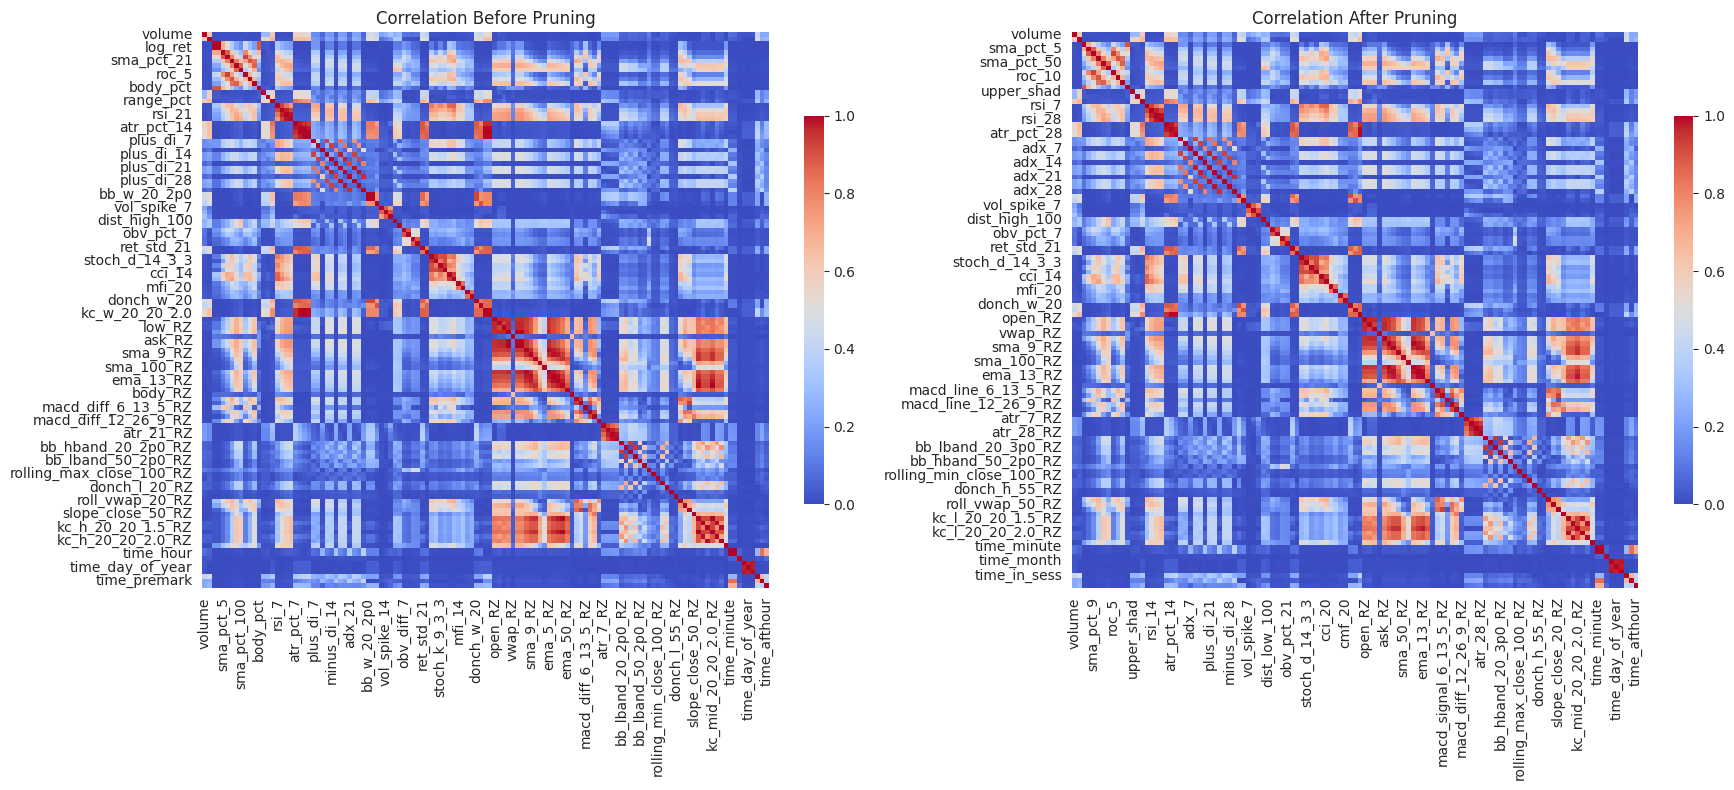

In [7]:
# importlib.reload(feats) ##### 

kept_feats, pruned_feats, corr_full, corr_pruned = feats.prune_features_by_variance_and_correlation(
    X_all=X_all,
    y=y,
    min_std=params.feats_min_std,
    max_corr=params.feats_max_corr,
)

# show heatmaps
plots.plot_correlation_before_after(corr_full, corr_pruned)

In [8]:
# build final feature DataFrame with signal and all features kept
cols = strategy_cols_tick_raw + params.signals_cols_tick + kept_feats
df_sign_allfeats = df_allfeats_sign[list(dict.fromkeys(cols)) ] # remove duplicates, keep order

params.to_parquet_with_progress(df_sign_allfeats, params.sign_featall_parquet)
df_sign_allfeats

Saving Parquet: 100%|██████████| 96/96 [00:17<00:00,  5.56it/s]


,atr_21_raw,adx_21_raw,rsi_21_raw,vwap_ohlc_close_session_raw,close_raw,targ_signal,signal_thresh,volume,trade_count,ret,sma_pct_5,sma_pct_9,sma_pct_21,sma_pct_50,sma_pct_100,roc_5,roc_10,roc_21,body_pct,upper_shad,lower_shad,range_pct,rsi_7,rsi_14,rsi_21,rsi_28,atr_pct_7,atr_pct_14,atr_pct_28,plus_di_7,minus_di_7,adx_7,plus_di_14,minus_di_14,adx_14,plus_di_21,minus_di_21,adx_21,plus_di_28,minus_di_28,adx_28,bb_w_20_3p0,bb_w_50_2p0,vol_spike_7,vol_spike_14,vol_spike_28,dist_high_100,dist_low_100,obv_diff_7,obv_pct_7,obv_diff_21,obv_pct_21,ret_std_21,ret_std_63,stoch_k_14_3_3,stoch_d_14_3_3,stoch_k_9_3_3,stoch_d_9_3_3,cci_14,cci_20,mfi_14,mfi_20,cmf_14,cmf_20,donch_w_20,donch_w_55,kc_w_20_20_2.0,open_RZ,high_RZ,low_RZ,vwap_RZ,ask_RZ,sma_5_RZ,sma_9_RZ,sma_21_RZ,sma_50_RZ,sma_100_RZ,ema_5_RZ,ema_9_RZ,ema_13_RZ,ema_50_RZ,body_RZ,macd_line_6_13_5_RZ,macd_signal_6_13_5_RZ,macd_diff_6_13_5_RZ,macd_line_12_26_9_RZ,macd_signal_12_26_9_RZ,macd_diff_12_26_9_RZ,atr_7_RZ,atr_14_RZ,atr_21_RZ,atr_28_RZ,bb_lband_20_2p0_RZ,bb_hband_20_2p0_RZ,bb_lband_20_3p0_RZ,bb_hband_20_3p0_RZ,bb_lband_50_2p0_RZ,bb_hband_50_2p0_RZ,obv_RZ,rolling_max_close_100_RZ,rolling_min_close_100_RZ,donch_h_20_RZ,donch_l_20_RZ,donch_h_55_RZ,donch_l_55_RZ,roll_vwap_20_RZ,roll_vwap_50_RZ,slope_close_20_RZ,slope_close_50_RZ,kc_l_20_20_1.5_RZ,kc_h_20_20_1.5_RZ,kc_mid_20_20_2.0_RZ,kc_l_20_20_2.0_RZ,kc_h_20_20_2.0_RZ,vwap_ohlc_close_session_RZ,time_minute,time_hour,time_dow,time_month,time_day_of_year,time_week_of_year,time_in_sess,time_premark,time_afthour
2016-01-04 08:41:00,0.011762,58.242894,31.248657,25.919854,25.927500,0.0,0.240933,0.003023,0.000000,0.500433,0.500950,0.511810,0.526240,0.339391,0.054104,0.505822,0.529551,0.538291,0.502137,0.0,0.0,0.000000,0.675790,0.350281,0.228420,0.149897,0.017626,0.097027,0.203224,0.556633,0.249792,0.193095,0.189627,0.382543,0.437282,0.103564,0.436844,0.754897,0.058622,0.470842,0.926057,0.037881,1.000000,0.262218,0.294462,0.300642,0.739402,0.089498,0.448973,0.450447,0.447875,0.429134,0.046163,1.000000,1.000000,1.000000,1.000000,1.000000,0.655600,0.666264,1.000000,0.784011,0.500129,0.500545,0.024417,0.726850,0.158790,0.470902,0.449365,0.498870,0.491161,0.471957,0.472634,0.475853,0.478770,0.477482,0.492120,0.472445,0.472295,0.472961,0.486983,0.511841,0.483754,0.483087,0.493819,0.483687,0.486641,0.485203,0.147190,0.167322,0.177302,0.184914,0.630173,0.332640,0.706100,0.261543,0.674394,0.283114,0.322518,0.666667,0.308970,0.500458,0.438132,0.781190,0.104200,0.513289,0.515093,0.486696,0.486609,0.530982,0.419012,0.476479,0.550646,0.404506,0.461592,0.299306,0.270833,0.500000,0.500000,0.508219,0.500000,0.0,1.0,0.0
2016-01-04 08:42:00,0.011202,57.694835,31.248657,25.919967,25.927500,0.0,0.240933,0.003033,0.000000,0.500433,0.500950,0.507511,0.523720,0.363440,0.062025,0.498969,0.524688,0.530953,0.502137,0.0,0.0,0.000000,0.675790,0.350281,0.228420,0.149897,0.014747,0.089745,0.195645,0.556633,0.249792,0.207808,0.189627,0.382543,0.422541,0.103564,0.436844,0.746749,0.058622,0.470842,0.922065,0.038054,0.957092,0.254786,0.269816,0.289320,0.739402,0.089498,0.449092,0.450646,0.447988,0.429368,0.045213,1.000000,1.000000,1.000000,1.000000,1.000000,0.639657,0.651093,1.000000,0.775197,0.500129,0.500545,0.024417,0.726850,0.150514,0.470902,0.449365,0.498870,0.491161,0.471957,0.472634,0.574331,0.577110,0.353421,0.334730,0.572345,0.571075,0.571578,0.376061,0.511841,0.363969,0.600341,0.369499,0.600114,0.599524,0.343532,0.062435,0.078197,0.086170,0.092016,0.715506,0.412788,0.792029,0.341572,0.751325,0.212727,0.342258,0.666667,0.308970,0.500458,0.438132,0.781190,0.104200,0.634861,0.374998,0.600107,0.606504,0.634966,0.317525,0.376590,0.655559,0.302403,0.569826,0.300000,0.270833,0.500000,0.500000,0.508219,0.500000,0.0,1.0,0.0
2016-01-04 08:43:00,0.010788,57.235099,30.635100,25.919976,25.925000,0.0,0.240933,0.000130,0.000000,0.472846,0.480815,0.488814,0.511523,0.380856,0.065207,0.486635,0.511078,0.517619,0.502137,0.0,0.0,0.000000,0.483186,0.330117,0.220325,0.144542,0.01